# Persona Vectors: A Detailed Look at Extraction

A slower, checked-at-every-step version of sections 1-5 of `persona_vectors_2.ipynb`: setup, the core idea, extracting persona vectors, looking at their structure, and layer-wise analysis. It stops before steering.

What is different from notebook 2:
- Every operation is explained and inspected (tokenization, tensor shapes; the hidden-state indexing convention is *verified*, not just stated).
- Extraction uses the paper repo's real trait files at full size: 5 instruction pairs x 20 questions per trait (notebook 2 used 1 pair x 3 questions).
- Conclusions come with checks: bootstrap uncertainty over questions, split-half reliability, and held-out discriminability on questions the vector never saw.

**Model**: Qwen/Qwen2.5-7B-Instruct. **Traits**: optimistic, evil, sycophantic, humorous.

**Not done here (be aware):** the paper filters extraction responses with an LLM judge (keeping only runs that clearly express the trait and stay coherent). That needs an API, so this notebook uses every response and shows samples so you can see where a "positive" run did not really express the trait.

**Run order and caching:** sections 1-2 are cheap. Section 3 generates 1,120 responses and caches everything to `Claude/persona_vectors/ckpt/extraction_deep_dive/`; after a kernel restart, rerunning it just reloads the cache. Sections 4-5 only analyse cached tensors.

In [1]:
import os

# Use only the locally cached model (no Hub network calls) and pin to the RTX 4090 by UUID
# (GPU index order varies between boots on this machine).
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-3185d7f6-fae1-0c3e-25f3-ad3e260d30b8"

import gc
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd()
PERSONA_VECTORS_DIR = REPO_ROOT / "Claude" / "persona_vectors"
assert PERSONA_VECTORS_DIR.exists(), f"Expected cloned repo at {PERSONA_VECTORS_DIR}"
CKPT_DIR = PERSONA_VECTORS_DIR / "ckpt" / "extraction_deep_dive"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TRAITS = ["optimistic", "evil", "sycophantic", "humorous"]

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print(f"PyTorch {torch.__version__}, CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print(f"Cache dir: {CKPT_DIR}")

PyTorch 2.6.0+cu124, CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090
Cache dir: /home/rob/PythonEnvironments/PersonaVectors/PersonaVectors/Claude/persona_vectors/ckpt/extraction_deep_dive


## 1. Setup and model loading

We load **Qwen2.5-7B-Instruct**, a *causal language model*: given text, it predicts the next token, and text is generated by repeating that. We use the **Instruct** variant because persona instructions are delivered as a system prompt inside a chat format, which the Instruct model was trained to follow.

- **fp16** stores each weight in 16 bits: about 15 GB for the 7.6 billion parameters, versus about 30 GB in 32-bit floats.
- **`device_map="auto"`** lets the `accelerate` library place the model on the GPU. The environment cell pins a single GPU, so everything lands on it.
- **`model.eval()`** switches off training-only behaviour such as dropout. It does not change any weights.

The printout below is the ground truth for the numbers used everywhere else: the number of layers (which determines how many hidden states there are) and the hidden size (the length of every activation vector).

In [2]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

t0 = time.time()
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto", torch_dtype=torch.float16)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()
print(f"Loaded in {time.time() - t0:.0f}s")

cfg = model.config
n_layers = cfg.num_hidden_layers
hidden_size = cfg.hidden_size
n_params = sum(p.numel() for p in model.parameters())
print(f"model_type={cfg.model_type}, layers={n_layers}, hidden_size={hidden_size}, heads={cfg.num_attention_heads}, vocab={cfg.vocab_size}")
print(f"parameters: {n_params / 1e9:.2f} B; fp16 weights ~ {n_params * 2 / 1e9:.1f} GB")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB")
print(f"pad_token={tokenizer.pad_token!r}, eos_token={tokenizer.eos_token!r}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded in 12s
model_type=qwen2, layers=28, hidden_size=3584, heads=28, vocab=152064
parameters: 7.62 B; fp16 weights ~ 15.2 GB
GPU memory allocated: 15.2 GB
pad_token='<|endoftext|>', eos_token='<|im_end|>'


### The chat template and tokenization

The model does not see plain text; it sees **token ids**. A *chat template* wraps each message in special marker tokens that say who is speaking (system, user, assistant). We render prompts with `apply_chat_template(..., add_generation_prompt=True)`: the final flag appends the *assistant-turn header*, so the model continues by writing the answer.

Later code tokenizes text with `add_special_tokens=False`. The chat template has already inserted every special token the model needs, and letting the tokenizer add more could duplicate them. The cell below prints the rendered prompt, its token ids as decoded pieces, and checks whether the default setting would have made any difference for this tokenizer.

`prompt_len` (the number of tokens in the rendered prompt) is the boundary used throughout the notebook: positions before it are **prompt** tokens, positions at or after it in "prompt + response" text are **response** tokens.

In [3]:
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "What is 2+2?"},
]
rendered = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print("Rendered prompt (repr):")
print(repr(rendered))

ids = tokenizer(rendered, add_special_tokens=False).input_ids
print(f"\n{len(ids)} tokens")
print([tokenizer.decode([i]) for i in ids])

ids_default = tokenizer(rendered).input_ids
print(f"\nSame ids with default special-token handling (Qwen adds none by default)? {ids == ids_default}")

prompt_len = len(ids)
print(f"prompt_len = {prompt_len}: positions >= {prompt_len} in prompt+response text are 'response'.")

Rendered prompt (repr):
'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 2+2?<|im_end|>\n<|im_start|>assistant\n'

26 tokens
['<|im_start|>', 'system', '\n', 'You', ' are', ' a', ' helpful', ' assistant', '.', '<|im_end|>', '\n', '<|im_start|>', 'user', '\n', 'What', ' is', ' ', '2', '+', '2', '?', '<|im_end|>', '\n', '<|im_start|>', 'assistant', '\n']

Same ids with default special-token handling (Qwen adds none by default)? True
prompt_len = 26: positions >= 26 in prompt+response text are 'response'.


### Hidden states and the indexing convention

A transformer is a stack of layers. Each layer reads a vector for every token and rewrites it. Those per-token vectors are the **hidden states** (also called activations), and they are where persona vectors live.

Calling the model with `output_hidden_states=True` returns a tuple of `n_layers + 1 = 29` tensors, each of shape `[batch, sequence_length, 3584]`:
- **entry 0** is the token embeddings (the input to layer 0);
- **entry `i`** (for `i >= 1`) is meant to be the output of `model.model.layers[i-1]`.

Getting this off-by-one wrong would silently put the steering hook, or a vector slice, one layer away from where you meant. So instead of trusting the description, the cell below **checks it**: it attaches a hook to every layer to capture its output during a normal forward pass, and compares each captured tensor with `hidden_states[i+1]`.

What to expect, stated as an expectation and not a fact: equality for the early layers. The last hidden state may differ, because Hugging Face models normally apply the model's final normalization to the last entry before returning it. The output reports whatever was actually found.

In [4]:
inputs = tokenizer(rendered, return_tensors="pt", add_special_tokens=False).to(model.device)
with torch.no_grad():
    out = model(**inputs, output_hidden_states=True)
hs = out.hidden_states
print(f"type={type(hs).__name__}, entries={len(hs)}, each shape={tuple(hs[0].shape)}, dtype={hs[0].dtype}")

emb = model.model.embed_tokens(inputs.input_ids)
print(f"hidden_states[0] equals the embedding lookup exactly: {torch.equal(hs[0], emb)}")

captured = {}
def make_hook(i):
    def hook(module, args, output):
        captured[i] = (output[0] if isinstance(output, tuple) else output).detach()
    return hook

handles = [model.model.layers[i].register_forward_hook(make_hook(i)) for i in range(n_layers)]
with torch.no_grad():
    model(**inputs)
for h in handles:
    h.remove()

rows = []
for i in range(n_layers):
    diff = (captured[i].float() - hs[i + 1].float()).abs().max().item()
    rows.append({"model.layers[i]": i, "hidden_states[i+1]": i + 1, "max_abs_diff": diff, "exactly_equal": torch.equal(captured[i], hs[i + 1])})
check = pd.DataFrame(rows)
print(check.to_string(index=False))
n_equal = int(check["exactly_equal"].sum())
print(f"\n{n_equal} of {n_layers} layers match hidden_states[i+1] exactly.")
last = check.iloc[-1]
print(f"Last layer (i={n_layers - 1}): exactly_equal={last['exactly_equal']}, max_abs_diff={last['max_abs_diff']:.4f}")

type=tuple, entries=29, each shape=(1, 26, 3584), dtype=torch.float16
hidden_states[0] equals the embedding lookup exactly: True
 model.layers[i]  hidden_states[i+1]  max_abs_diff  exactly_equal
               0                   1      0.000000           True
               1                   2      0.000000           True
               2                   3      0.000000           True
               3                   4      0.000000           True
               4                   5      0.000000           True
               5                   6      0.000000           True
               6                   7      0.000000           True
               7                   8      0.000000           True
               8                   9      0.000000           True
               9                  10      0.000000           True
              10                  11      0.000000           True
              11                  12      0.000000           True
             

**What the check found:** the embeddings match exactly, and layers 0-26 match `hidden_states[1]`-`hidden_states[27]` exactly. Only the very last entry, `hidden_states[28]`, differs from the raw output of `model.model.layers[27]` (by a large amount). The hypothesis is the model's **final normalization**: Hugging Face applies `model.model.norm` to the last layer's output before returning it as the last hidden state. The next cell tests that directly instead of assuming it.

In [5]:
# Hypothesis: hidden_states[28] == model.model.norm(output of layers[27]).
normed = model.model.norm(captured[n_layers - 1])
print(f"hidden_states[{n_layers}] equals model.model.norm(layers[{n_layers - 1}] output) exactly: {torch.equal(normed, hs[n_layers])}")
print(f"max_abs_diff: {(normed.float() - hs[n_layers].float()).abs().max().item():.6f}")

before = hs[n_layers - 1].float().norm(dim=-1).mean().item()
after = hs[n_layers].float().norm(dim=-1).mean().item()
print(f"\nMean activation length (L2 norm per token): hidden_states[{n_layers - 1}] = {before:.1f}, hidden_states[{n_layers}] (after final norm) = {after:.1f}")
print("Implication: the last hidden state is on a different scale from the others, so vector lengths at that layer")
print("are not directly comparable with earlier layers (this matters for the 'longest vector' comparisons in section 4).")

hidden_states[28] equals model.model.norm(layers[27] output) exactly: True
max_abs_diff: 0.000000

Mean activation length (L2 norm per token): hidden_states[27] = 541.4, hidden_states[28] (after final norm) = 284.0
Implication: the last hidden state is on a different scale from the others, so vector lengths at that layer
are not directly comparable with earlier layers (this matters for the 'longest vector' comparisons in section 4).


## 2. The core idea

A **persona vector** is the difference between two averages of hidden states:

`persona_vector = mean(activations | positive instruction) - mean(activations | negative instruction)`

computed separately at every layer. Why does a *difference of means* give something useful?
- Anything that is the same in both conditions (the topic of the question, the language, most of what the model is "thinking about") appears in both averages and **cancels** in the subtraction.
- What remains is whatever *systematically differs* between the conditions, which, if the instructions differ mainly in the trait, is the trait.

The result is a **direction** in the 3,584-dimensional activation space: an arrow with both a *direction* (which way it points) and a *length* (how far apart the two averages are). Two operations use it:
- **Projection** of an activation `a` onto the vector `v`: `(a . v) / ||v||`. How far `a` lies *along* that direction, in the same units as the activations. It grows if `a` grows.
- **Cosine similarity**: `(a . v) / (||a|| ||v||)`. Only the *angle* between them, always in [-1, 1], unchanged if `a` is scaled.

The toy example below uses invented 3-D data so every step can be seen and checked by hand. The real data has 3,584 dimensions per layer, but the arithmetic is identical.

pos mean: [1.901 1.045 0.149]
neg mean: [-0.003  0.959 -0.157]
vector  : [1.904 0.086 0.306] (dim 0 large; dims 1-2 near 0 because they do not differ between conditions)
matches a direct sum-and-divide computation: True

Example point [2.1 1.  0.1]: projection=2.132, cosine=0.916
Same point scaled x3: projection=6.395 (grows), cosine=0.916 (unchanged)

Mean projection: positive=1.945, negative=0.015
ROC-AUC of the projection for telling the conditions apart: 0.993


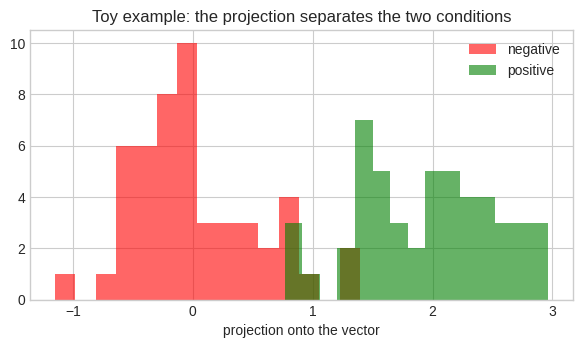

In [6]:
rng = np.random.default_rng(0)
# Two conditions in 3-D. Only dimension 0 carries the "trait": it is higher in the positive condition.
pos = rng.normal(loc=[2.0, 1.0, 0.0], scale=0.5, size=(50, 3))
neg = rng.normal(loc=[0.0, 1.0, 0.0], scale=0.5, size=(50, 3))

pos_mean, neg_mean = pos.mean(axis=0), neg.mean(axis=0)
v = pos_mean - neg_mean
print("pos mean:", pos_mean.round(3))
print("neg mean:", neg_mean.round(3))
print("vector  :", v.round(3), "(dim 0 large; dims 1-2 near 0 because they do not differ between conditions)")

direct = pos.sum(axis=0) / len(pos) - neg.sum(axis=0) / len(neg)
assert np.allclose(v, direct)
print("matches a direct sum-and-divide computation: True")

def projection(a, vec):
    return a @ vec / np.linalg.norm(vec)

def cosine(a, vec):
    return a @ vec / (np.linalg.norm(a) * np.linalg.norm(vec))

x = np.array([2.1, 1.0, 0.1])
print(f"\nExample point {x}: projection={projection(x, v):.3f}, cosine={cosine(x, v):.3f}")
print(f"Same point scaled x3: projection={projection(3 * x, v):.3f} (grows), cosine={cosine(3 * x, v):.3f} (unchanged)")

proj_pos, proj_neg = projection(pos, v), projection(neg, v)
print(f"\nMean projection: positive={proj_pos.mean():.3f}, negative={proj_neg.mean():.3f}")
y = np.r_[np.ones(len(pos)), np.zeros(len(neg))]
print(f"ROC-AUC of the projection for telling the conditions apart: {roc_auc_score(y, np.r_[proj_pos, proj_neg]):.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(proj_neg, bins=15, alpha=0.6, label="negative", color="red")
ax.hist(proj_pos, bins=15, alpha=0.6, label="positive", color="green")
ax.set_xlabel("projection onto the vector")
ax.set_title("Toy example: the projection separates the two conditions")
ax.legend()
plt.show()

### What to look for in real data

Sections 3-5 apply exactly this recipe to real activations. The toy test above (does the projection separate the two conditions?) becomes a **held-out test**: extract the vector from one set of questions, then check whether it still separates positive from negative runs on questions it never saw. ROC-AUC summarizes that: 0.5 means no separation, 1.0 means perfect separation.

One caution that applies from here on: in the toy data the two conditions differ *only* in the trait dimension. Real positive/negative runs also differ in other ways (the instruction text itself, response length, style), and a difference of means captures all of them. Later sections check what can be checked, and state what cannot.

**Reading the toy output:** the vector came out as about `[1.90, 0.09, 0.31]`. Dimension 0 dominates, as designed, but the other components are not exactly 0: each average comes from only 50 noisy samples, so small spurious components appear (the standard error of each mean difference is roughly 0.5 x sqrt(2/50) = 0.1, and 0.31 is on the high side of that). The projection separates the conditions well (AUC 0.993) but not perfectly, partly for the same reason. Section 4 measures this kind of sampling uncertainty for the real vectors.